# 07 LangGraph Core

By the end you can design a custom graph shape (workflow TypedDict + routing) and wire the agent loop LangChain compiles for you in nb 03.



Set up the project path and reload shared helpers from this repo.


In [1]:
import sys
import importlib
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "shared").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from dotenv import load_dotenv
load_dotenv(ROOT / ".env")

for _name in (
    "shared.dataflow",
    "shared.notebook_display",
    "shared.llm",
    "shared.bootcamp_fixtures",
):
    importlib.reload(importlib.import_module(_name))

print(f"Project root: {ROOT}")


c:\Users\Azooo\langchain-bootcamp\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project root: c:\Users\Azooo\langchain-bootcamp


Verify DeepSeek credentials before running LangGraph cells.


In [2]:
import os

def env_status():
    keys = {
        "DEEPSEEK_API_KEY": bool(os.getenv("DEEPSEEK_API_KEY")),
        "DEEPSEEK_MODEL": os.getenv("DEEPSEEK_MODEL", "deepseek-v4-flash"),
        "LLM_PROVIDER": os.getenv("LLM_PROVIDER", "deepseek"),
        "TAVILY_API_KEY": bool(os.getenv("TAVILY_API_KEY")),
        "LANGSMITH_API_KEY": bool(os.getenv("LANGSMITH_API_KEY")),
    }
    for k, v in keys.items():
        print(f"{k}: {v}")
    return keys

ENV = env_status()


DEEPSEEK_API_KEY: True
DEEPSEEK_MODEL: deepseek-v4-flash
LLM_PROVIDER: deepseek
TAVILY_API_KEY: True
LANGSMITH_API_KEY: True


Load the chat model helper used by live cells below.


In [3]:
import os
from shared.llm import get_model

def require_llm():
    return get_model()


Import DATAFLOW printers and ask_approval once. These label every graph step, in later cells, read preview() lines to see state moving between nodes like spell components chaining together.


In [4]:
from shared.dataflow import preview, print_dataflow, print_agent_dataflow, print_final_state
from shared.notebook_display import ask_approval


See reducers in action: two nodes append to the same list channel. Without Annotated[..., operator.add], the second node would wipe the first, notice the output keeps both Alfama walk and Pastéis de nata.


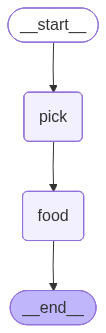

After: {'destination': 'Riyadh', 'activities': ['Drinking Coffe', 'Eating Shaworma at zoq almzaq']}


In [5]:
import operator
from typing import Annotated, TypedDict
from langgraph.graph import StateGraph, START, END

class TravelState(TypedDict):
    destination: str
    activities: Annotated[list[str], operator.add]

def pick(state): return {"destination": "Riyadh", "activities": ["Drinking Coffe"]}
def food(state): return {"activities": ["Eating Shaworma at zoq almzaq"]}

g = StateGraph(TravelState)
g.add_node("pick", pick)
g.add_node("food", food)
g.add_edge(START, "pick")
g.add_edge("pick", "food")
g.add_edge("food", END)
reducer_graph = g.compile()

from IPython.display import Image, display

display(Image(reducer_graph.get_graph().draw_mermaid_png()))
print("After:", reducer_graph.invoke({"destination": "", "activities": []}))


Define TravelSupportState, the spell book every node reads and writes. TypedDict fields are your channels; list fields use reducers so parallel steps can merge safely. Print confirms every key the workflow will pass along.


In [6]:
import operator
from typing import Annotated, TypedDict

class TravelSupportState(TypedDict):
    request: str
    traveler_profile: dict
    classification: dict
    search_results: Annotated[list[str], operator.add]
    draft_reply: str
    risk_flags: Annotated[list[str], operator.add]
    needs_human: bool
    final_reply: str

def empty_state(**overrides) ->  TravelSupportState:
    base: TravelSupportState = {
        "request": "",
        "traveler_profile": {},
        "classification": {},
        "search_results": [],
        "draft_reply": "",
        "risk_flags": [],
        "needs_human": False,
        "final_reply": "",
    }
    base.update(overrides)
    return base

print("State fields: ", list(TravelSupportState.__annotations__.keys()))


State fields:  ['request', 'traveler_profile', 'classification', 'search_results', 'draft_reply', 'risk_flags', 'needs_human', 'final_reply']


Implement LLM nodes and wire the full support_graph, classify with Pydantic, search the KB, route with conditional edges. Each function returns a partial dict; compile once into support_graph.


In [10]:
from typing import Literal

from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import END, START, StateGraph
from pydantic import BaseModel, Field

from shared.bootcamp_fixtures import search_kb
from shared.llm import get_model


model = get_model()
BASE_SYSTEM = (
    "You are a professional travel support agent. Be concise, accurate, and policy-grounded."
)


def llm(system: str, user: str) -> str:
    """One-shot model call for nodes that do not need structured output."""
    reply = model.invoke([SystemMessage(content=system), HumanMessage(content=user)])
    return str(reply.content).strip()


# Structured classification (Pydantic shape, not hand-parsed JSON)
class TravelClassification(BaseModel):
    intent: str = Field(description="support, booking, or general")
    urgency: Literal["low", "normal", "high"] = "normal"
    topic: str = Field(description="docs, booking, or itinerary")
    needs_human: bool = False


classifier = model.with_structured_output(TravelClassification, method="function_calling")


# Nodes: each function returns only the fields it changes 
def read_request(state: TravelSupportState):
    """Normalize input and default missing traveler profile."""
    return {
        "request": state["request"],
        "traveler_profile": state.get("traveler_profile") or {"loyalty": "standard"},
    }


def classify_intent(state: TravelSupportState):
    """Classify ticket; may set needs_human before routing."""
    data = classifier.invoke([
        SystemMessage(content=f"{BASE_SYSTEM} Classify the ticket into the schema fields."),
        HumanMessage(content=state["request"]),
    ]).model_dump()
    return {"classification": data, "needs_human": data["needs_human"]}


def doc_search(state: TravelSupportState):
    """Docs path: pull policy snippets from the KB."""
    return {"search_results": search_kb(state["request"])}


def booking_risk(state: TravelSupportState):
    """Booking path: detect risky requests before auto-reply."""
    raw = llm(
        f"{BASE_SYSTEM} Return comma-separated risk flag labels only (or empty).",
        state["request"],
    )
    flags = [f.strip() for f in raw.split(",") if f.strip() and f.strip().lower() != "none"]
    return {"risk_flags": flags, "needs_human": bool(flags) or state.get("needs_human", False)}


def draft_reply(state: TravelSupportState):
    """Draft reply from KB facts and any risk flags."""
    facts = "; ".join(state["search_results"][:]) or "No KB facts."
    flags = ", ".join(state["risk_flags"]) or "none"
    text = llm(
        f"{BASE_SYSTEM} Draft helpful customer-facing replies using provided facts.",
        f"Request: {state['request']}\nFacts: {facts}\nRisk flags: {flags}",
    )
    return {"draft_reply": text}


def quality_gate(state: TravelSupportState):
    """Final check before send; escalate if flags or needs_human is set."""
    return {"needs_human": state["needs_human"] or bool(state["risk_flags"])}


def human_review(state: TravelSupportState):
    """Stand-in for human approval — notebook 09 uses interrupt() instead."""
    return {"draft_reply": f"[PENDING HUMAN] {state['request'][:120]}"}


def send_reply(state: TravelSupportState):
    """Publish draft as the customer-facing final reply."""
    return {"final_reply": state["draft_reply"]}


# Routers: return the name of the next node 
def route_after_classify(state: TravelSupportState) -> Literal["doc_search", "booking_risk", "human_review"]:
    if state["needs_human"]:
        return "human_review"
    topic = state["classification"].get("topic", "docs")
    return "booking_risk" if topic == "booking" else "doc_search"


def route_after_quality(state: TravelSupportState) -> Literal["human_review", "send_reply"]:
    return "human_review" if state["needs_human"] else "send_reply"



builder = StateGraph(TravelSupportState)
builder.add_node("read_request", read_request)
builder.add_node("classify", classify_intent)
builder.add_node("doc_search", doc_search)
builder.add_node("booking_risk", booking_risk)
builder.add_node("draft_reply", draft_reply)
builder.add_node("quality_gate", quality_gate)
builder.add_node("human_review", human_review)
builder.add_node("send_reply", send_reply)

builder.add_edge(START, "read_request")
builder.add_edge("read_request", "classify")
builder.add_conditional_edges("classify", route_after_classify, ["doc_search", "booking_risk", "human_review"])
builder.add_edge("doc_search", "draft_reply")
builder.add_edge("booking_risk", "draft_reply")
builder.add_edge("draft_reply", "quality_gate")
builder.add_conditional_edges("quality_gate", route_after_quality, ["human_review", "send_reply"])
builder.add_edge("human_review", "send_reply")
builder.add_edge("send_reply", END)

support_graph = builder.compile()
print("Graph ready:", type(support_graph).__name__)


Graph ready: CompiledStateGraph


Render the compiled graph as Mermaid PNG. Use this picture to trace routing before you spend tokens running the workflow.


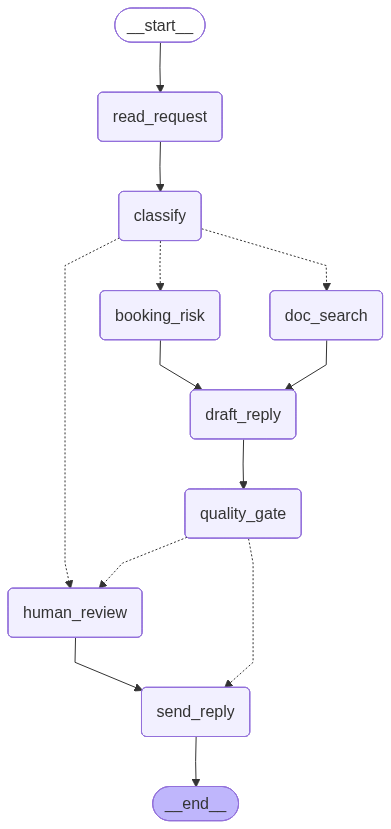

In [11]:
from IPython.display import Image, display

# Show workflow
display(Image(support_graph.get_graph().draw_mermaid_png()))


Run two tickets through support_graph and read DATAFLOW for each. Compare doc vs booking paths, different nodes fire, same state shape at the end. Look for needs_human and final_reply in the last line.


In [12]:

for label, req in [
    ("DOC CASE", "What are Schengen visa stay limits?"),
    ("BOOKING CASE", "Urgent refund for cancelled Lisbon flight"),
]:
    print("\n" + "=" * 60)
    print(label)
    print_dataflow(support_graph, empty_state(request=req))



DOC CASE
DATAFLOW
0. input: {'request': 'What are Schengen visa stay limits?', 'traveler_profile': {}, 'classification': {}, 'search_results': [], 'draft_reply': '', 'risk_flags': [], 'needs_human': False, 'f...
1. read_request: {'request': 'What are Schengen visa stay limits?', 'traveler_profile': "{'loyalty': 'standard'}"}
2. classify: {'classification': "{'intent': 'general', 'urgency': 'low', 'topic': 'docs', 'needs_human': False}", 'needs_human': 'False'}
3. doc_search: {'search_results': "['Schengen visa: short stays up to 90 days in any 180-day period.']"}
4. draft_reply: {'draft_reply': 'The Schengen visa allows short stays of up to **90 days within any 180-day period**. This applies to the entire Schengen Area, not per country. Please ensure you do not exceed this...'}
5. quality_gate: {'needs_human': 'False'}
6. send_reply: {'final_reply': 'The Schengen visa allows short stays of up to **90 days within any 180-day period**. This applies to the entire Schengen Area, not per c

Command(update=..., goto=...) routes and writes state in one return, dynamic edges without extra nodes. Invoke with topic booking; output path should end at booking_handler_done.


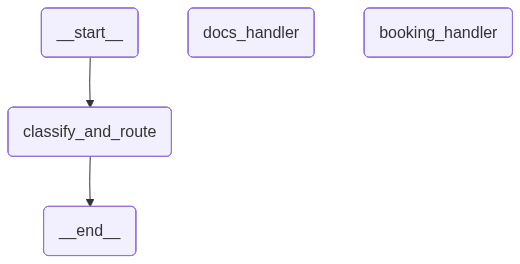

Routed to: docs_handler_done


In [14]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.types import Command

class RouteState(TypedDict):
    topic: str
    path: str

def classify_and_route(state: RouteState):
    if state["topic"] == "booking":
        return Command(update={"path": "booking"}, goto="booking_handler")
    return Command(update={"path": "docs"}, goto="docs_handler")

g = StateGraph(RouteState)
g.add_node("classify_and_route", classify_and_route)
g.add_node("docs_handler", lambda _: {"path": "docs_handler_done"})
g.add_node("booking_handler", lambda _: {"path": "booking_handler_done"})
g.add_edge(START, "classify_and_route")
g.add_edge("docs_handler", END)
g.add_edge("booking_handler", END)
route_cmd_graph = g.compile()

from IPython.display import Image, display

display(Image(route_cmd_graph.get_graph().draw_mermaid_png()))
print("Routed to:", route_cmd_graph.invoke({"topic": "doc", "path": ""})["path"])


Build the agent loop: agent node, ToolNode, tools_condition until the model answers. This is the loop create_agent() compiles for you in nb 03, same CompiledStateGraph runtime, custom workflow above used a different graph shape. DATAFLOW should show tool_calls then a final AIMessage.


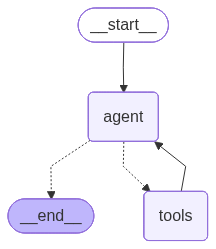

DATAFLOW
[0] HumanMessage: Beach trip under $600
[1] AIMessage tool_calls: ["search_destinations({'query': 'beach', 'budget': 600})"]
[2] ToolMessage(search_destinations): Phuket — $450
[3] AIMessage: Here's a great option for you:  🏖️ **Phuket, Thailand — $450**  This is well within your $600 budget! Phuket is a stunning tropical paradise known for its beautiful beaches, crysta...
FINAL: Here's a great option for you:  🏖️ **Phuket, Thailand — $450**  This is well within your $600 budget! Phuket is a stunning tropical paradise known for its beautiful beaches, crysta...
Same runtime as nb 03: CompiledStateGraph


In [16]:
from langchain_core.messages import SystemMessage
from langgraph.graph import MessagesState, StateGraph, START
from langgraph.prebuilt import ToolNode, tools_condition
from shared.bootcamp_fixtures import search_destinations
from shared.llm import get_model

model = get_model().bind_tools([search_destinations])

def agent_node(state):
    sys = SystemMessage(content="Travel assistant. Use search_destinations for trip ideas.")
    return {"messages": [model.invoke([sys] + list(state["messages"]))]}

g = StateGraph(MessagesState)
g.add_node("agent", agent_node)
g.add_node("tools", ToolNode([search_destinations]))
g.add_edge(START, "agent")
g.add_conditional_edges("agent", tools_condition)
g.add_edge("tools", "agent")
agent_graph = g.compile()

from IPython.display import Image, display

display(Image(agent_graph.get_graph().draw_mermaid_png()))
out = agent_graph.invoke({"messages": [{"role": "user", "content": "Beach trip under $600"}]})
print_agent_dataflow(out["messages"])
print("Same runtime as nb 03:", type(agent_graph).__name__)
